## Imports

In [813]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

## Parameters

### Inputs

In [814]:
radnet_input_df = pd.read_csv("../inputs/radnet_input.csv")
radnet_input_class = radnet_input_df['label'].values
radnet_input_efsr = radnet_input_df['efsr_edge'].values

### Outputs

In [815]:
inference_output_df = pd.read_csv("../outputs/inference_output.csv")
inference_output_class = inference_output_df['class'].values
inference_output_confidence = inference_output_df['confidence'].values

In [816]:
fuzzy_output_df = pd.read_csv("../outputs/fuzzy_output.csv")
fuzzy_output_class = fuzzy_output_df['class'].values
fuzzy_output_confidence = fuzzy_output_df['confidence'].values

In [817]:
kalman_output_df = pd.read_csv("../outputs/kalman_output.csv")
kalman_output_class = kalman_output_df['class'].values
kalman_output_confidence = kalman_output_df['confidence'].values

## Confiança

### Confiança x Arestas

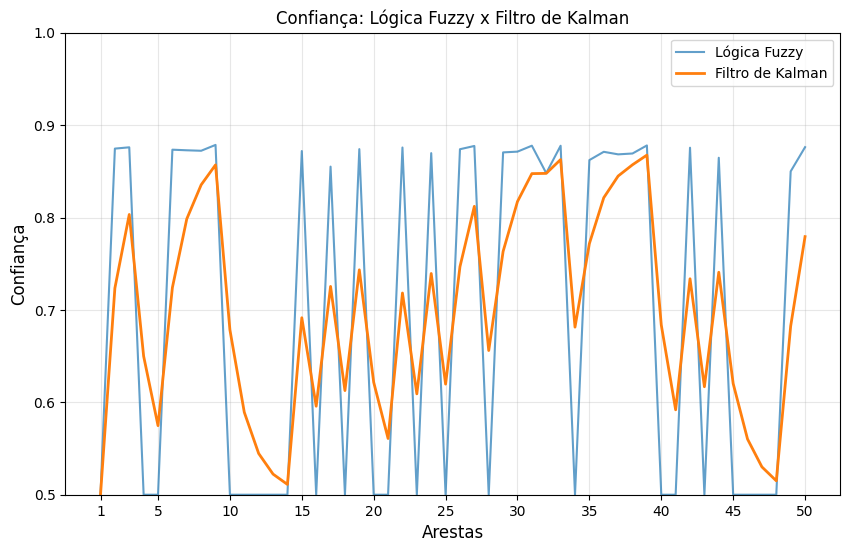

In [818]:
plt.figure(figsize=(10,6))

x_values = np.arange(1, len(fuzzy_output_confidence) + 1)

plt.plot(x_values, fuzzy_output_confidence, label="Lógica Fuzzy", alpha=0.7)
plt.plot(x_values, kalman_output_confidence, label="Filtro de Kalman", linewidth=2)

plt.title("Confiança: Lógica Fuzzy x Filtro de Kalman", fontsize=12)
plt.xlabel("Arestas", fontsize=12)
plt.ylabel("Confiança", fontsize=12)

plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 1)

n = len(fuzzy_output_confidence)
ticks = [1] + list(range(5, n + 1, 5))
plt.xticks(ticks)

os.makedirs("../results", exist_ok=True)
plt.savefig('../results/fuzzy_logic_kalman_filter.png', bbox_inches='tight')
plt.show()

## Classificação

### Lógica Fuzzy

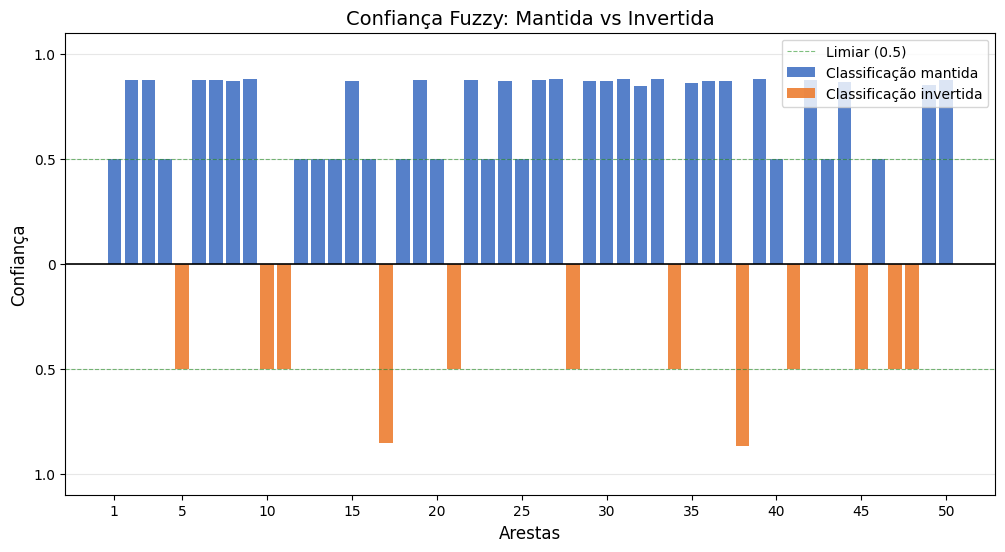

In [819]:
plt.figure(figsize=(12, 6))

x_values = np.arange(1, len(fuzzy_output_class) + 1)

conf_mantida = fuzzy_output_confidence.copy()
conf_invertida = np.zeros(len(fuzzy_output_confidence))

indices_invertidos = np.where(fuzzy_output_class != inference_output_class)[0]

conf_mantida[indices_invertidos] = 0

for i in indices_invertidos:
    conf_invertida[i] = -fuzzy_output_confidence[i]

plt.bar(x_values, conf_mantida, color='#4472C4', label='Classificação mantida', alpha=0.9)
plt.bar(x_values, conf_invertida, color='#ED7D31', label='Classificação invertida', alpha=0.9)

plt.title("Confiança Fuzzy: Mantida vs Invertida", fontsize=14)
plt.xlabel("Arestas", fontsize=12)
plt.ylabel("Confiança", fontsize=12)
plt.ylim(-1.1, 1.1)
plt.axhline(y=0, color='black', linewidth=1.2, linestyle='-')
plt.axhline(y=0.5, color='green', linewidth=0.8, linestyle='--', alpha=0.5, label='Limiar (0.5)')
plt.axhline(y=-0.5, color='green', linewidth=0.8, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, alpha=0.3, axis='y')

n = len(fuzzy_output_class)
ticks = [1] + list(range(5, n + 1, 5))
plt.xticks(ticks)

y_ticks = [-1.0, -0.5, 0, 0.5, 1.0]
y_labels = ['1.0', '0.5', '0', '0.5', '1.0']
plt.yticks(y_ticks, y_labels)

os.makedirs("../results", exist_ok=True)
plt.savefig('../results/fuzzy_confidence_inverted.png', bbox_inches='tight', dpi=300)
plt.show()

### Filtro de Kalman

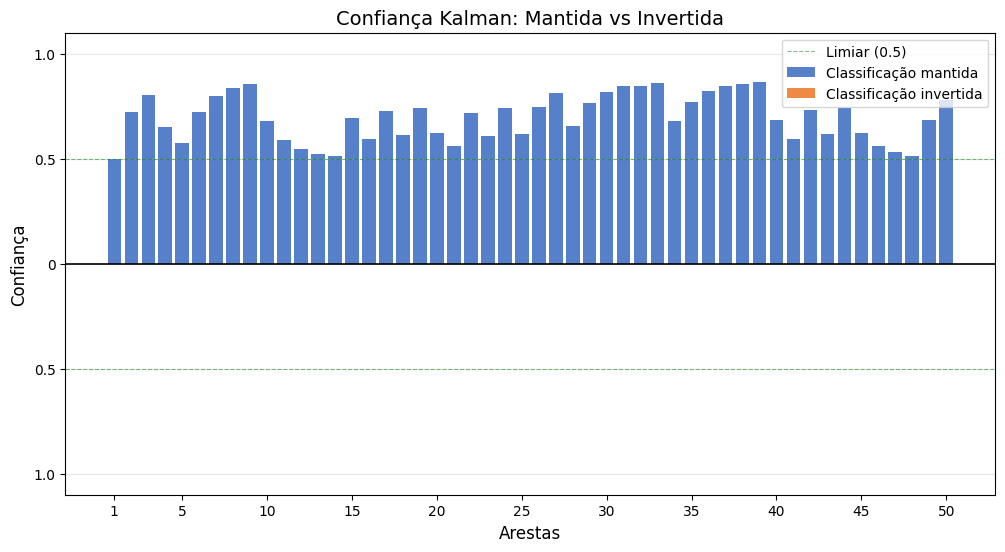

In [820]:
plt.figure(figsize=(12, 6))

x_values = np.arange(1, len(kalman_output_class) + 1)

conf_mantida = kalman_output_confidence.copy()
conf_invertida = np.zeros(len(kalman_output_confidence))

indices_invertidos = np.where(kalman_output_class != fuzzy_output_class)[0]

conf_mantida[indices_invertidos] = 0

for i in indices_invertidos:
    conf_invertida[i] = -kalman_output_confidence[i]

plt.bar(x_values, conf_mantida, color='#4472C4', label='Classificação mantida', alpha=0.9)
plt.bar(x_values, conf_invertida, color='#ED7D31', label='Classificação invertida', alpha=0.9)

plt.title("Confiança Kalman: Mantida vs Invertida", fontsize=14)
plt.xlabel("Arestas", fontsize=12)
plt.ylabel("Confiança", fontsize=12)
plt.ylim(-1.1, 1.1)
plt.axhline(y=0, color='black', linewidth=1.2, linestyle='-')
plt.axhline(y=0.5, color='green', linewidth=0.8, linestyle='--', alpha=0.5, label='Limiar (0.5)')
plt.axhline(y=-0.5, color='green', linewidth=0.8, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, alpha=0.3, axis='y')

n = len(kalman_output_class)
ticks = [1] + list(range(5, n + 1, 5))
plt.xticks(ticks)

y_ticks = [-1.0, -0.5, 0, 0.5, 1.0]
y_labels = ['1.0', '0.5', '0', '0.5', '1.0']
plt.yticks(y_ticks, y_labels)

os.makedirs("../results", exist_ok=True)
plt.savefig('../results/kalman_confidence_inverted.png', bbox_inches='tight', dpi=300)
plt.show()

## Matrizes de Confusão

### Ground Truth

In [821]:
def create_ground_truth(class_a, class_b, confidence_a, confidence_b, threshold=0.5):
    ground_truth = []
    
    for i in range(len(class_a)):
        score_a = confidence_a[i] if class_a[i] == 1 else (1 - confidence_a[i])
        score_b = confidence_b[i] if class_b[i] == 1 else (1 - confidence_b[i])
        
        score = (score_a + score_b) / 2
        
        if score > threshold:
            ground_truth.append(1)
        else:
            ground_truth.append(0)
    
    return np.array(ground_truth)

In [822]:
# Normalização
radnet_input_confidence = np.clip((radnet_input_efsr - 0.20) / (0.98 - 0.20), 0, 1)

In [823]:
ground_truth = create_ground_truth(
    radnet_input_class, 
    inference_output_class,
    radnet_input_confidence,
    inference_output_confidence
)

### Matriz de Confusão: Lógica Fuzzy

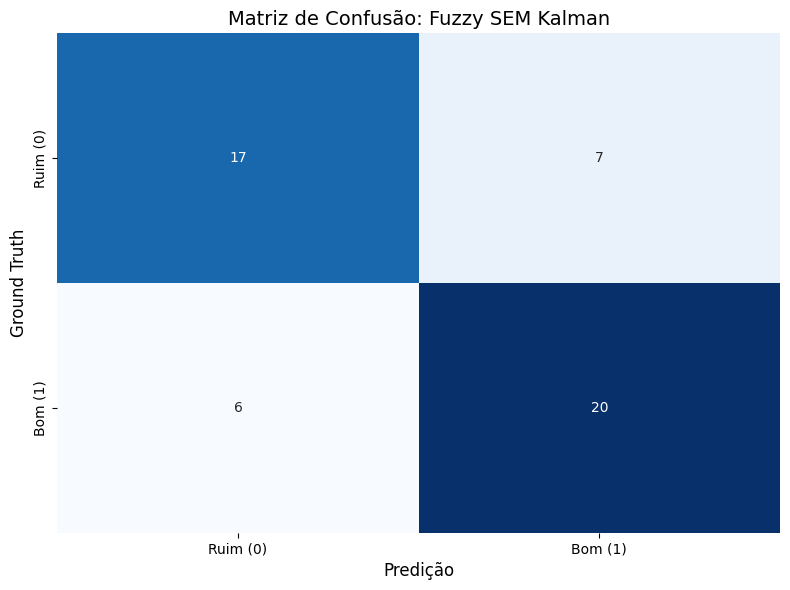

Fuzzy SEM Kalman
-------------------------
Acurácia:        74.00%
Precisão:        74.07%
Recall:          76.92%
F1:              75.47%


In [824]:
acc = accuracy_score(ground_truth, fuzzy_output_class)
precision = precision_score(ground_truth, fuzzy_output_class)
recall = recall_score(ground_truth, fuzzy_output_class)
f1 = f1_score(ground_truth, fuzzy_output_class)

cm = confusion_matrix(ground_truth, fuzzy_output_class)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Ruim (0)', 'Bom (1)'], 
            yticklabels=['Ruim (0)', 'Bom (1)'])
plt.xlabel('Predição', fontsize=12)
plt.ylabel('Ground Truth', fontsize=12)
plt.title(f'Matriz de Confusão: Fuzzy SEM Kalman', fontsize=14)
plt.tight_layout()

os.makedirs("../results", exist_ok=True)
plt.savefig('../results/confusion_matrix_fuzzy_without_kalman.png', bbox_inches='tight')
plt.show()

print("Fuzzy SEM Kalman")
print("-" * 25)
print(f"Acurácia:        {acc*100:.2f}%")
print(f"Precisão:        {precision*100:.2f}%")
print(f"Recall:          {recall*100:.2f}%")
print(f"F1:              {f1*100:.2f}%")

### Matriz de Confusão: Filtro de Kalman

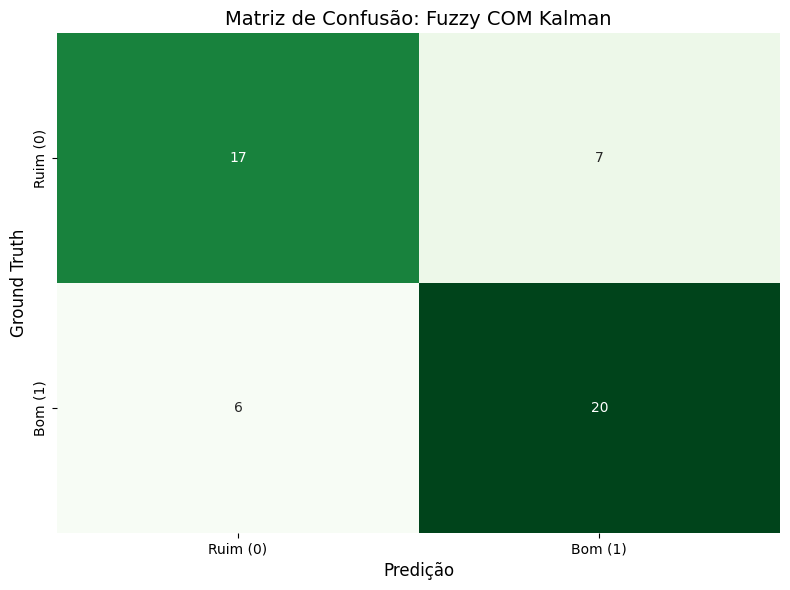

Fuzzy COM Kalman
-------------------------
Acurácia:        74.00%
Precisão:        74.07%
Recall:          76.92%
F1:              75.47%


In [825]:
acc = accuracy_score(ground_truth, kalman_output_class)
precision = precision_score(ground_truth, kalman_output_class)
recall = recall_score(ground_truth, kalman_output_class)
f1 = f1_score(ground_truth, kalman_output_class)

cm = confusion_matrix(ground_truth, kalman_output_class)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Ruim (0)', 'Bom (1)'], 
            yticklabels=['Ruim (0)', 'Bom (1)'])
plt.xlabel('Predição', fontsize=12)
plt.ylabel('Ground Truth', fontsize=12)
plt.title(f'Matriz de Confusão: Fuzzy COM Kalman', fontsize=14)
plt.tight_layout()

plt.savefig('../results/confusion_matrix_fuzzy_with_kalman.png', bbox_inches='tight')
plt.show()

print("Fuzzy COM Kalman")
print("-" * 25)
print(f"Acurácia:        {acc*100:.2f}%")
print(f"Precisão:        {precision*100:.2f}%")
print(f"Recall:          {recall*100:.2f}%")
print(f"F1:              {f1*100:.2f}%")